Mapping particle tracks from Parcels unto Salish Sea Atlantis Model polygons. 
Original code written by Bec Gordon & Javier Porobic, CSIRO.
Link to the [SSAM Ocean Parcels Repo](https://bitbucket.csiro.au/users/por07g/repos/ssam_oceanparcels/browse)
Particles are injected mostly at the surface with a percentage at depth in Haro Strait.

This notebook includes containment after 48 hours, and calculates the water soluble fraction (WSF) of pseudo-components of PAHs, grouped by log(k_{ow}) as follows: Naphthalene (log(Kow) 3.2 - 3.5) = Naphthalene (C0-C4), Acenaphthylene; Phenanthrene (log(Kow) 3.8 - 4.6) = Phenanthrene (C0-C4), Acenaphthene, Fluorene, Anthracene; Pyrene(log(Kow) 4.9 - 5.2) = Pyrene, Fluoranthene; Benzo (log(Kow) 5.7 - 6.5) = Chrysene, benzo(e)pyrene, benzo(a)pyrene, perylene, Indeno(1,2,3-cd)pyrene, Benz(a)anthracene, Benzo(b)fluoranthene, Benzo(k)fluoranthene. 

In [1]:
import os
import xarray as xr
import numpy as np
import geopandas as gpd
import pandas as pd
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from shapely.geometry import MultiPoint

In [2]:
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
#data_df_original = data_df_original
data_df = data_df_original.sort_values(by=['BOX_ID']).set_index('BOX_ID')
box_depth = data_df['BOTZ']
box_area = data_df['AREA']

In [3]:
surface_layer = []
for box in range(0,130):
    if data_df.iloc[box].BOTZ < 26:
        slayer = 0
    elif data_df.iloc[box].BOTZ == 50:
        slayer = 1
    elif data_df.iloc[box].BOTZ == 100:
        slayer = 2
    elif data_df.iloc[box].BOTZ == 250:
        slayer = 3
    elif data_df.iloc[box].BOTZ > 250 and box_depth[box] < 401:
        slayer = 4
    elif data_df.iloc[box].BOTZ > 400:
        slayer = 5
    surface_layer.append(slayer)

In [4]:
# Oil type properties & spill location selection

Dilbit = {
    "Density": 984.6, #kg/m^3 17% mass loss
    "Naphthalene": 627, #mg/kg oil
    "Phenanthrene": 1396,
    "Pyrene": 15,
    "Benzo": 279,
}

WSFmean = {
    "Naphthalene": 0.47,
    "Phenanthrene": 0.093,
    "Pyrene": 0.0035,
    "Benzo": 0.0035,
}

WSFmax = {
    "Naphthalene": 0.79,
    "Phenanthrene": 0.15,
    "Pyrene": 0.006,
    "Benzo": 0.006,
}

WSFmin = {
    "Naphthalene": 0.28,
    "Phenanthrene": 0.061,
    "Pyrene": 0.0021,
    "Benzo": 0.0021,
}

spill_box_layer_volume = {
    "5b" : (322271112.331102*25), # Turn Point/Haro Strait (m^3, area x 25m depth)
}

In [150]:
# Ocean Parcels Spill File

inputFileName = '5b_TurnPoint_Dilbit_2020-10-20'
num_particles = 10000
file_path = 'results/' + inputFileName + '_'+ str(num_particles) +'_OP_D50_wp3.zarr'

In [151]:
fuel_type = Dilbit #BunkerC
spill_volume = 2000

In [152]:
scenario = inputFileName.split(sep = '_')

In [153]:
# Calculations of oil per particle in mg/m^3/particle
release_start = scenario[3]
oil_per_particle = (fuel_type["Density"] * spill_volume / spill_box_layer_volume[scenario[0]]) / num_particles #kg/m3
naph_per_particle = oil_per_particle * fuel_type["Naphthalene"] * WSFmean["Naphthalene"]
phen_per_particle = oil_per_particle * fuel_type["Phenanthrene"] * WSFmean["Phenanthrene"]
pyrene_per_particle = oil_per_particle * fuel_type["Pyrene"] * WSFmean["Pyrene"]
benzo_per_particle = oil_per_particle * fuel_type["Benzo"] * WSFmean["Benzo"]
tpah_per_particle = naph_per_particle + phen_per_particle + pyrene_per_particle + benzo_per_particle
release_start_time = np.datetime64(release_start)

In [154]:
# Calculations of oil mass in mg
oil_mass_kg = (fuel_type["Density"] * spill_volume)
naph_mass_mg = oil_mass_kg * fuel_type["Naphthalene"] * WSFmean["Naphthalene"]
phen_mass_mg = oil_mass_kg * fuel_type["Phenanthrene"] * WSFmean["Phenanthrene"]
pyrene_mass_mg = oil_mass_kg * fuel_type["Pyrene"] * WSFmean["Pyrene"]
benzo_mass_mg = oil_mass_kg * fuel_type["Benzo"] * WSFmean["Benzo"]
oil_mass_mg = oil_mass_kg * 1e6

print(str(scenario[2])+' spill mass of '+str(oil_mass_mg)+' in mg')
print('Naphthalene spill mass of '+str(naph_mass_mg)+' in mg')
print('Phenanthrene spill mass of '+str(phen_mass_mg)+' in mg')
print('Pyrene spill mass of '+str(pyrene_mass_mg)+' in mg')
print('Benzo spill mass of '+str(benzo_mass_mg)+' in mg')

Dilbit spill mass of 1969200000000.0 in mg
Naphthalene spill mass of 580303548.0 in mg
Phenanthrene spill mass of 255657297.6 in mg
Pyrene spill mass of 103383.0 in mg
Benzo spill mass of 1922923.8 in mg


In [155]:
numLayers = 7
numBoxes = data_df.shape[0]
outputDT = 43100.00
print('numBoxes = ' + str(numBoxes))

numBoxes = 130


In [156]:
pfile = xr.open_zarr(file_path) #.to_netcdf(new_file_name)

In [157]:
#an array of times that correspond to Atlantis timesteps and 48 hour containment
time_slice = np.arange(0,len(pfile.time[0]),12) #or any N

In [158]:
time_slice

array([  0,  12,  24,  36,  48,  60,  72,  84,  96, 108, 120, 132, 144,
       156, 168, 180, 192, 204, 216, 228, 240])

In [159]:
time_slice = time_slice[0:5]
time_slice

array([ 0, 12, 24, 36, 48])

In [160]:
reduced_pfile = pfile.isel(obs=(time_slice))

In [161]:
reduced_pfile

<xarray.Dataset>
Dimensions:      (trajectory: 10003, obs: 5)
Coordinates:
  * obs          (obs) int32 0 12 24 36 48
  * trajectory   (trajectory) int64 195 237 ... -9223372036854775808
Data variables:
    age          (trajectory, obs) float64 dask.array<chunksize=(204, 1), meta=np.ndarray>
    beached      (trajectory, obs) float64 dask.array<chunksize=(204, 1), meta=np.ndarray>
    decay_value  (trajectory, obs) float32 dask.array<chunksize=(204, 1), meta=np.ndarray>
    lat          (trajectory, obs) float64 dask.array<chunksize=(204, 1), meta=np.ndarray>
    lon          (trajectory, obs) float64 dask.array<chunksize=(204, 1), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] dask.array<chunksize=(204, 1), meta=np.ndarray>
    z            (trajectory, obs) float64 dask.array<chunksize=(204, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_mesh:           spherical
    parcels_version:        2.4.2

In [162]:
# pulling all variables from Parcels
lon = reduced_pfile.variables['lon']
time = reduced_pfile.variables['time']

In [163]:
numParticles = lon.shape[0]
numSteps = len(time[0,:])

print('numParticles = ' + str(numParticles))
print('numSteps = ' + str(numSteps))

numParticles = 10003
numSteps = 5


In [164]:
minDate = np.datetime64(release_start+"T00:30:00")
ts = pd.to_datetime(str(minDate))
d = ts.strftime('%Y-%m-%d %H:%M:%S')
print(d)

2020-10-20 00:30:00


In [165]:
# Create the netcdf output file

netcdfFileName = "results/ForcingFiles/MPRI2_Scenario_"+scenario[0]+"_"+ scenario[3] + "_" + str(num_particles) + "_WSF_contained.nc"
try:
    os.remove(netcdfFileName)
except:
    pass
ncfile = Dataset(netcdfFileName, "w", format="NETCDF4", clobber=True)
Dataset.set_fill_on(ncfile)

# Dimensions
t = ncfile.createDimension("t", None)
b = ncfile.createDimension("b", numBoxes)
z = ncfile.createDimension("z", numLayers)

In [166]:
# Variables
times = ncfile.createVariable("t",np.float64, ("t",))
TPAH = ncfile.createVariable("TPAH",np.float64,("t", "b"))
Naphthalene = ncfile.createVariable("Naphthalene",np.float64, ("t", "b", "z"))
Phenanthrene = ncfile.createVariable("Phenanthrene",np.float64,("t", "b", "z"))
Pyrene = ncfile.createVariable("Pyrene",np.float64,("t", "b", "z"))
Benzo = ncfile.createVariable("Benzo",np.float64,("t", "b", "z"))

# Attributes
Naphthalene.units = "mgPAH/m^3"
Naphthalene.long_name = "Naphthalene"
Naphthalene.missing_value = 0.0000
Naphthalene.valid_min = 0.0000
Naphthalene.valid_max = 100000000.0

Phenanthrene.units = "mgPAH/m^3"
Phenanthrene.long_name = "Phenanthrene"
Phenanthrene.missing_value = 0.0000
Phenanthrene.valid_min = 0.0000
Phenanthrene.valid_max = 100000000.0

Pyrene.units = "mgPAH/m^3"
Pyrene.long_name = "Pyrene"
Pyrene.missing_value = 0.0000
Pyrene.valid_min = 0.0000
Pyrene.valid_max = 100000000.0

Benzo.units = "mgPAH/m^3"
Benzo.long_name = "Benzo(a)pyrene"
Benzo.missing_value = 0.0000
Benzo.valid_min = 0.0000
Benzo.valid_max = 100000000.0

TPAH.units = "mgPAH/m^3"
TPAH.long_name = "Total Water Soluble Fraction PAH Concentration"

times.units = "seconds since " + d
times.dt = outputDT
times.long_name = "time"

In [167]:
# Populate variables with contaminant data

timeData = np.arange(0,(len(time[0,:]))*outputDT,outputDT)
times[:] = timeData

No_layer_particles = np.zeros((numSteps, numBoxes))
Box_particles = np.zeros((numSteps, numBoxes, numLayers))

In [168]:
for timeValue in range(0, numSteps):

    lats = reduced_pfile['lat'][:,timeValue].values
    lons = reduced_pfile['lon'][:,timeValue].values
    points = np.column_stack((lons, lats))
    multi_point = MultiPoint(points)

    for box_number in range (0, numBoxes):
        layer = surface_layer[box_number]
        box_coordinates = data_df.iloc[box_number].geometry
        found_particles = np.array([box_coordinates.contains(point) for point in multi_point])
        num_particles_within_box = np.sum(found_particles)
        No_layer_particles[timeValue][box_number] = No_layer_particles[timeValue][box_number] + num_particles_within_box
        if layer ==0:
            Box_particles[timeValue][box_number][layer] = Box_particles[timeValue][box_number][layer] + num_particles_within_box
        elif layer ==1:    
            Box_particles[timeValue][box_number][layer] = Box_particles[timeValue][box_number][layer] + num_particles_within_box*0.84
            Box_particles[timeValue][box_number][layer-1] = Box_particles[timeValue][box_number][layer-1] + num_particles_within_box*0.16
        elif layer >=2:
            Box_particles[timeValue][box_number][layer] = Box_particles[timeValue][box_number][layer] + num_particles_within_box*0.84
            Box_particles[timeValue][box_number][layer-1] = Box_particles[timeValue][box_number][layer-1] + num_particles_within_box*0.14
            Box_particles[timeValue][box_number][layer-2] = Box_particles[timeValue][box_number][layer-2] + num_particles_within_box*0.02
        


TPAH[:,:] = No_layer_particles * tpah_per_particle
Naphthalene[:,:,:] = Box_particles * naph_per_particle
Phenanthrene[:,:,:] = Box_particles * phen_per_particle
Pyrene[:,:,:] = Box_particles * pyrene_per_particle
Benzo[:,:,:] = Box_particles * benzo_per_particle

ncfile.close()

In [169]:
np.histogram(No_layer_particles)

(array([637,   5,   1,   2,   4,   0,   0,   0,   0,   1]),
 array([    0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,  7000.,
         8000.,  9000., 10000.]))

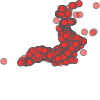

In [170]:
multi_point